In [2]:
%pip install tensorflow opencv-python matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
import tensorflow as tf
import numpy as np
import os
import cv2
from matplotlib import pyplot as plt

In [43]:
train_data = tf.keras.utils.image_dataset_from_directory('brain_mri_dataset/Training')

Found 5600 files belonging to 4 classes.


In [44]:
data_iterator = train_data.as_numpy_iterator()

In [45]:
batch = data_iterator.next()

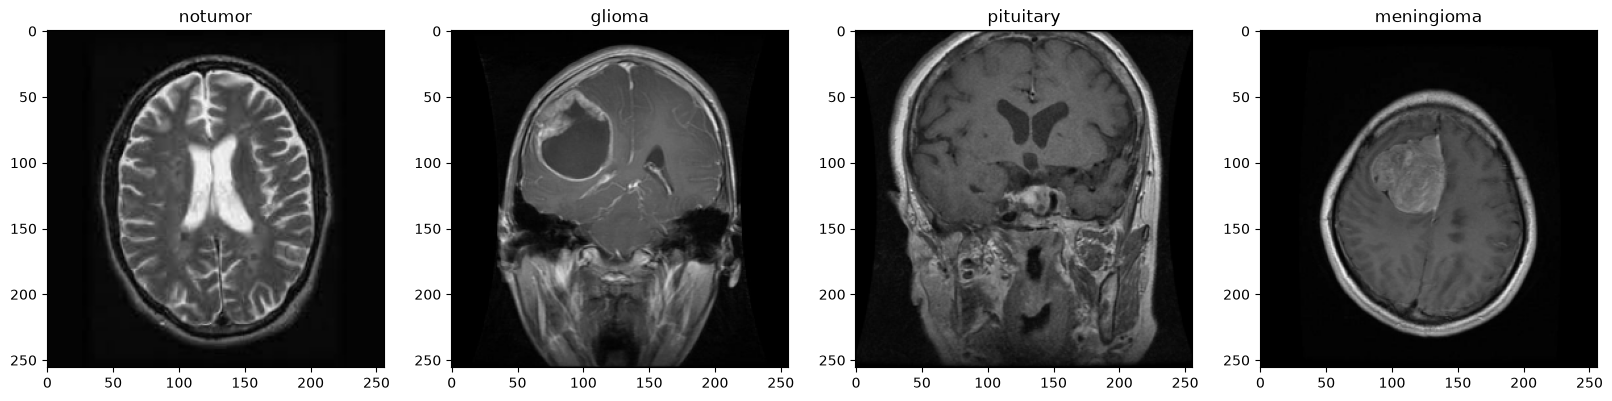

In [46]:
class_names = train_data.class_names
fig, ax = plt.subplots(ncols = 4, figsize = (20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(class_names[batch[1][idx]])

In [47]:
train_data = train_data.map(lambda x,y: (x/255, y))

In [51]:
scaled = train_data.as_numpy_iterator().next()

In [52]:
scaled[0].max()

np.float32(1.0)

In [53]:
train_size = int(len(train_data) * 0.8)
val_size = len(train_data) - train_size
train = train_data.take(train_size)
val = train_data.skip(train_size)

In [54]:
test_data = tf.keras.utils.image_dataset_from_directory('brain_mri_dataset/Testing')
test_data = test_data.map(lambda x, y: (x/255, y))

Found 1600 files belonging to 4 classes.


In [58]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout

In [71]:
model = Sequential()

model.add(Conv2D(16, (3,3), 1, activation ='relu', input_shape = (256,256,3)))
model.add(MaxPooling2D())

model.add(Conv2D(32, (3,3), 1, activation ='relu'))
model.add(MaxPooling2D())

model.add(Conv2D(16, (3,3), 1, activation ='relu'))
model.add(MaxPooling2D())

model.add(Flatten())

model.add(Dense(256, activation ='relu'))
model.add(Dense(4, activation ='softmax'))

In [72]:
model.compile('adam', loss = tf.losses.SparseCategoricalCrossentropy(), metrics = ['accuracy'])

In [73]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)                   │ (None, 254, 254, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 127, 127, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_12 (Conv2D)                   │ (None, 125, 125, 32)        │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 62, 62, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 60, 60, 16)          │           4,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_11 (MaxPooling2D)      │ (None, 30, 30, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 14400)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 256)                 │       3,686,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 4)                   │           1,028 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,697,396 (14.10 MB)

 Trainable params: 3,697,396 (14.10 MB)

 Non-trainable params: 0 (0.00 B)

In [77]:
hist = model.fit(train, epochs = 20, validation_data = val)

Epoch 1/20


C:\Users\miken\OneDrive\Desktop\brain-tumor-detection\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


140/140 ━━━━━━━━━━━━━━━━━━━━ 65s 464ms/step - accuracy: 0.7408 - loss: 0.6555 - val_accuracy: 0.7804 - val_loss: 0.5331
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 61s 435ms/step - accuracy: 0.8775 - loss: 0.3350 - val_accuracy: 0.8705 - val_loss: 0.3711
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 61s 432ms/step - accuracy: 0.9201 - loss: 0.2130 - val_accuracy: 0.9250 - val_loss: 0.2144
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 38s 270ms/step - accuracy: 0.9531 - loss: 0.1250 - val_accuracy: 0.9187 - val_loss: 0.2481
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 40s 288ms/step - accuracy: 0.9806 - loss: 0.0588 - val_accuracy: 0.9500 - val_loss: 0.1788
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 55s 390ms/step - accuracy: 0.9855 - loss: 0.0443 - val_accuracy: 0.9384 - val_loss: 0.2109
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 24s 172ms/step - accuracy: 0.9922 - loss: 0.0237 - val_accuracy: 0.9500 - val_loss: 0.1857
Epoch 8/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 80s 446ms/step - accuracy: 0.9958 - loss: 0.0143 - val

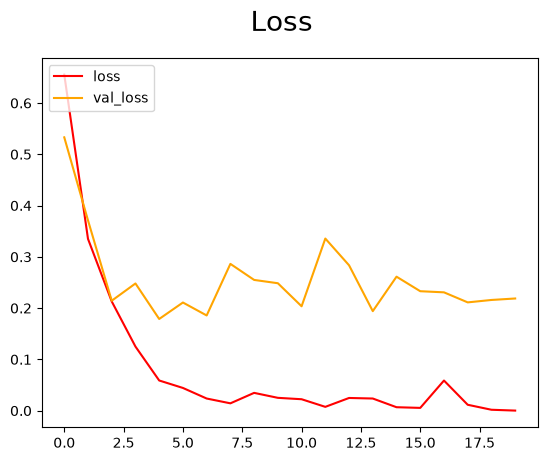

In [87]:
fig = plt.figure()
plt.plot(hist.history['loss'], color = 'red', label = 'loss')
plt.plot(hist.history['val_loss'], color = 'blue', label = 'val_loss')
fig.suptitle('Loss', fontsize = 20)
plt.legend(loc = "upper left")
plt.show()


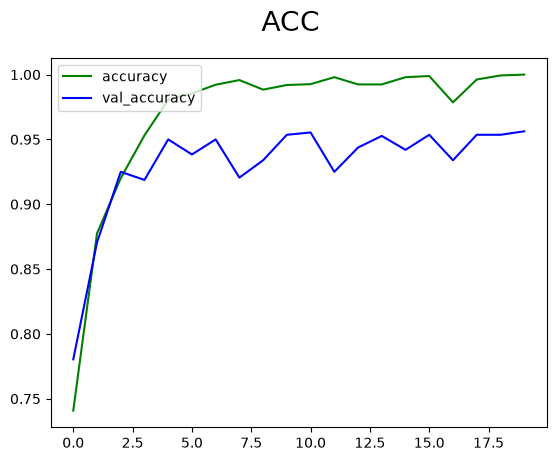

In [95]:
fig = plt.figure()
plt.plot(hist.history['accuracy'], color = 'green', label = 'accuracy')
plt.plot(hist.history['val_accuracy'], color = 'blue', label = 'val_accuracy')
fig.suptitle('ACC', fontsize = 20)
plt.legend(loc = "upper left")
plt.show()

In [94]:
model.evaluate(test_data)

50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 163ms/step - accuracy: 0.8744 - loss: 1.7238


[1.7238012552261353, 0.8743749856948853]